In [1]:
print("hi")

hi


In [2]:
import pandas as pd 

df_indices=pd.read_csv('/Users/mast/Documents/VInayPrograming/Thunder_storm_Predi/data/raw/indices data.csv')

df_surface=pd.read_csv('/Users/mast/Documents/VInayPrograming/Thunder_storm_Predi/data/raw/surface_data.csv')

In [16]:
df_indices.head()

,Year,Month,Date,GMT,SWEAT index,Showalter index,LIFTED index,K index,Cross totals index,Vertical totals index,Totals totals index,TLCL,PLCL,CINE,CAPE,PRECIPITABLE WATER,1000-500 THICKNESS,prob
1981,1,1,0,91.2,12.4,13.4,-1.4,3.0,21.7,24.7,284.41,993.98,0.0,0.0,22.8,5636,NaN,NaN
1981,1,1,12,66.0,9.3,8.0,0.0,6.2,22.7,28.9,281.75,856.09,0.0,0.0,24.7,5671,NaN,NaN
1981,1,2,0,75.7,10.2,11.3,1.6,10.2,20.1,30.3,282.11,956.13,0.0,0.0,20.4,5592,NaN,NaN
1981,1,2,12,111.7,8.5,7.5,0.8,13.1,20.1,33.2,280.44,836.26,0.0,0.0,23.0,5660,NaN,NaN
1981,1,3,12,64.0,2.1,-0.2,2.8,13.4,24.1,37.5,284.25,862.29,-260.5,0.8,19.7,5636,NaN,NaN


In [17]:
df_surface.head()

,INDEX,YEAR,MN,DT,MAX,MIN,AW,RF,EVP,DRNRF(hrs),...,T.1,G.1,DUR.1,T.2,G.2,DUR.2,T.3,G.3,DUR.3,Unnamed: 39
42809,1981,1,1,26.0,12.1,04,0.0,,,,...,,,,,,,,,,NaN
42809,1981,1,2,25.0,11.6,03,0.0,,,,...,4,045,,,,,,,,NaN
42809,1981,1,3,25.4,11.3,03,0.0,,,,...,2,260,,,,,,,,NaN
42809,1981,1,4,25.8,11.8,02,0.0,,,,...,2,150,,,,,,,,NaN
42809,1981,1,5,28.2,13.9,04,0.0,,,,...,,,,,,,,,,NaN


In [18]:
df_surface.describe()

,INDEX,YEAR,MN,DT,MAX,AW,Unnamed: 39
count,14397.000000,14397.000000,14397.000000,14360.000000,14377.000000,14391.000000,0.0
mean,2000.326179,6.517052,15.727026,31.855376,22.135988,4.729122,NaN
std,11.426269,3.452945,8.800485,3.940901,5.353824,14.312234,NaN
min,1981.000000,1.000000,1.000000,14.800000,6.600000,0.000000,NaN
25%,1990.000000,4.000000,8.000000,29.200000,18.000000,0.000000,NaN
50%,2000.000000,7.000000,16.000000,32.500000,24.300000,0.000000,NaN
75%,2010.000000,10.000000,23.000000,34.700000,26.400000,1.600000,NaN
max,2020.000000,12.000000,31.000000,43.100000,32.100000,383.200000,NaN


In [19]:
df_surface.shape

(14397, 40)

In [20]:
df_surface.isna().sum()

INDEX              0
YEAR               0
MN                 0
DT                37
MAX               20
MIN                0
AW                 6
RF                 0
EVP                0
DRNRF(hrs)         0
DRNRF(mnts)        0
SSH                0
TS                 0
N                  0
FFF                0
D                  0
TOCSQ              0
DU                 0
RA                 0
DZ                 0
SN                 0
SL                 0
HA                 0
TH                 0
DS                 0
FG                 0
GA                 0
T                  0
G                  0
DUR                0
T.1                0
G.1                0
DUR.1              0
T.2                0
G.2                0
DUR.2              0
T.3                0
G.3                0
DUR.3              0
Unnamed: 39    14397
dtype: int64

In [21]:
import numpy as np
df_surface=df_surface.replace(r'\s*$',np.nan,regex=True)

In [22]:
df_surface=df_surface.apply(pd.to_numeric,errors='coerce')
df_surface.corr()['AW'].sort_values()

INDEX         -0.010442
MN             0.006952
DT             0.009707
YEAR           0.068789
MAX            0.144268
AW             1.000000
MIN                 NaN
RF                  NaN
EVP                 NaN
DRNRF(hrs)          NaN
DRNRF(mnts)         NaN
SSH                 NaN
TS                  NaN
N                   NaN
FFF                 NaN
D                   NaN
TOCSQ               NaN
DU                  NaN
RA                  NaN
DZ                  NaN
SN                  NaN
SL                  NaN
HA                  NaN
TH                  NaN
DS                  NaN
FG                  NaN
GA                  NaN
T                   NaN
G                   NaN
DUR                 NaN
T.1                 NaN
G.1                 NaN
DUR.1               NaN
T.2                 NaN
G.2                 NaN
DUR.2               NaN
T.3                 NaN
G.3                 NaN
DUR.3               NaN
Unnamed: 39         NaN
Name: AW, dtype: float64

In [23]:
# import seaborn as sns 
# sns.scatterplot(x='MAX',y='AW',data=df_surface)
indixes_0gmt=df_indices[df_indices['GMT']==0].copy()
print(f"Original Indices shape: {df_indices.shape}")
print(f"Filtered (0 GMT) Indices shape: {indixes_0gmt.shape}")

Original Indices shape: (22449, 18)
Filtered (0 GMT) Indices shape: (0, 18)


In [24]:
df_surface['TH']=df_surface['TH'].fillna(0).astype(int)
df_surface['HA']=df_surface['HA'].fillna(0).astype(int)
df_surface['target']=((df_surface['TH']==1) | (df_surface['HA']==1)).astype(int)
print("Target DIstribution: ")
print(df_surface['target'].value_counts())


Target DIstribution: 
target
0    14397
Name: count, dtype: int64


In [30]:
df_surface[df_surface['target']==0]

,INDEX,YEAR,MN,DT,MAX,MIN,AW,RF,EVP,DRNRF(hrs),...,G.1,DUR.1,T.2,G.2,DUR.2,T.3,G.3,DUR.3,Unnamed: 39,target
42809,1981,1,1,26.0,12.1,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
42809,1981,1,2,25.0,11.6,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
42809,1981,1,3,25.4,11.3,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
42809,1981,1,4,25.8,11.8,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
42809,1981,1,5,28.2,13.9,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42809,2020,12,27,24.5,12.6,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
42809,2020,12,28,24.5,10.8,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
42809,2020,12,29,24.8,11.4,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
42809,2020,12,30,25.6,12.7,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [41]:
# A more robust fix that works even if you've already renamed columns
# 1. Normalize indixes_0gmt
for col in ['Year', 'Month', 'Date']:
    if col in indixes_0gmt.columns:
        indixes_0gmt[col] = pd.to_numeric(indixes_0gmt[col], errors='coerce').fillna(0).astype(int)

# 2. Rename df_surface if needed, then normalize
rename_map = {'YEAR': 'Year', 'MN': 'Month', 'DT': 'Date'}
df_surface = df_surface.rename(columns={k: v for k, v in rename_map.items() if k in df_surface.columns})

for col in ['Year', 'Month', 'Date']:
    if col in df_surface.columns:
        df_surface[col] = pd.to_numeric(df_surface[col], errors='coerce').fillna(0).astype(int)

# 3. Perform the Merge
df_merged = pd.merge(indixes_0gmt, df_surface[['Year', 'Month', 'Date', 'target']], 
                     on=['Year', 'Month', 'Date'], how='inner')

print(f"Merge successful! Rows found: {len(df_merged)}")
if len(df_merged) > 0:
    print("Now proceed to run the Feature Engineering cell again.")
else:
    print("Wait, still 0 rows? Let's check the date range of both datasets.")


Merge successful! Rows found: 0
Wait, still 0 rows? Let's check the date range of both datasets.


In [42]:
print(indixes_0gmt['Year'].unique()) 
print(df_surface['Year'].unique())

[]
[ 1  2  3  4  5  6  7  8  9 10 11 12]


In [44]:
# --- Diagnostic Step 1: Check Indices GMT ---
print("--- Indices GMT Raw Values ---")
print(f"Unique GMT values: {df_indices['GMT'].unique()}")
print(f"GMT Column Type: {df_indices['GMT'].dtype}")
# Check for hidden spaces if it's an object/string
if df_indices['GMT'].dtype == 'O':
    # print(f"Unique GMT values (with quotes): {[f'\"{v}\"' for v in df_indices['GMT'].unique()]}")
    print("Unique GMT values (with quotes):", [f'"{v}"' for v in df_indices['GMT'].unique()])


# --- Diagnostic Step 2: Check Surface Columns ---
print("\n--- Surface Data Head ---")
print(f"Surface Columns: {df_surface.columns.tolist()}")
display(df_surface.head(2))


--- Indices GMT Raw Values ---
Unique GMT values: [ 91.2  66.   75.7 ... 219.9  37.1 197.4]
GMT Column Type: float64

--- Surface Data Head ---
Surface Columns: ['INDEX', 'Year', 'Month', 'Date', 'MAX', 'MIN', 'AW', 'RF', 'EVP', 'DRNRF(hrs)', 'DRNRF(mnts)', 'SSH', 'TS', 'N', 'FFF', 'D', 'TOCSQ', 'DU', 'RA', 'DZ', 'SN', 'SL', 'HA', 'TH', 'DS', 'FG', 'GA', 'T', 'G', 'DUR', 'T.1', 'G.1', 'DUR.1', 'T.2', 'G.2', 'DUR.2', 'T.3', 'G.3', 'DUR.3', 'Unnamed: 39', 'target']


,INDEX,Year,Month,Date,MAX,MIN,AW,RF,EVP,DRNRF(hrs),...,G.1,DUR.1,T.2,G.2,DUR.2,T.3,G.3,DUR.3,Unnamed: 39,target
42809,1981,1,1,26,12.1,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
42809,1981,1,2,25,11.6,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [31]:
from IPython.display import  display


df_surface=df_surface.rename(columns={'YEAR':'Year','MN':'Month','DT':'Date'})
df_merged=pd.merge(indixes_0gmt,df_surface[['Year','Month','Date','target']],on=['Year','Month','Date'],how='inner')
print(f"Final Merged Dataset Shape: {df_merged.shape}")
display(df_merged.head())


Final Merged Dataset Shape: (0, 19)


,Year,Month,Date,GMT,SWEAT index,Showalter index,LIFTED index,K index,Cross totals index,Vertical totals index,Totals totals index,TLCL,PLCL,CINE,CAPE,PRECIPITABLE WATER,1000-500 THICKNESS,prob,target


In [34]:
print('Missing values before imputations:')
print(df_merged.isnull().sum().sum())



Missing values before imputations:
0


In [35]:
numeric_cols=df_merged.select_dtypes(include=[np.number]).columns
df_merged[numeric_cols]=df_merged[numeric_cols].fillna(df_merged[numeric_cols].median())

In [36]:
print("\nMissing values after imputation:", df_merged.isnull().sum().sum())


Missing values after imputation: 0


In [37]:
df_merged['Environmental Stability'] = df_merged['Showalter index'] + df_merged['LIFTED index']
df_merged['Convective Potential'] = df_merged['CAPE'] + df_merged['CINE']

df_merged = df_merged.rename(columns={
    'PRECIPITABLE WATER': 'Moisture Indices',
    '1000-500 THICKNESS': 'Temperature Pressure',
    'PLCL': 'Moisture Temperature Profiles'
})
print("New features created!")
display(df_merged[['Environmental Stability', 'Convective Potential', 'Moisture Indices', 'target']].head())

New features created!


,Environmental Stability,Convective Potential,Moisture Indices,target


In [38]:
# List of features specified in the project report
final_features = [
    'SWEAT index', 'K index', 'Totals totals index', 
    'Environmental Stability', 'Moisture Indices', 
    'Convective Potential', 'Temperature Pressure', 
    'Moisture Temperature Profiles', 'target'
]

# Create our training-ready dataframe
df_final = df_merged[final_features].copy()

print(f"Final Dataframe for training: {df_final.shape}")
display(df_final.describe())


Final Dataframe for training: (0, 9)


,SWEAT index,K index,Totals totals index,Environmental Stability,Moisture Indices,Convective Potential,Moisture Temperature Profiles,target
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
## >> Main Steps.(data preprocessing and handling missing values)

import pandas as pd
import numpy as np

# 1. Load data correctly by disabling automatic indexing
df_indices = pd.read_csv('../data/raw/indices data.csv', index_col=False)
df_surface = pd.read_csv('../data/raw/surface_data.csv', index_col=False, skipinitialspace=True)

# 2. Clean Surface data whitespace (as we did before)
df_surface = df_surface.replace(r'^\s*$', np.nan, regex=True)

# 3. Handle the Target Variable in Surface
df_surface['TH'] = df_surface['TH'].fillna(0).astype(int)
df_surface['HA'] = df_surface['HA'].fillna(0).astype(int)
df_surface['target'] = ((df_surface['TH'] == 1) | (df_surface['HA'] == 1)).astype(int)

# 4. Normalize Date columns to Integers (to avoid '01' vs '1' mismatch)
# Rename surface headers first
rename_map = {'YEAR': 'Year', 'MN': 'Month', 'DT': 'Date'}
df_surface = df_surface.rename(columns=rename_map)

# Force both to numeric
for col in ['Year', 'Month', 'Date']:
    df_indices[col] = pd.to_numeric(df_indices[col], errors='coerce').fillna(0).astype(int)
    df_surface[col] = pd.to_numeric(df_surface[col], errors='coerce').fillna(0).astype(int)

# 5. Filter for 0 GMT (Now that GMT is fixed and not 91.2!)
df_indices_0gmt = df_indices[df_indices['GMT'] == 0].copy()

# 6. Join
df_merged = pd.merge(df_indices_0gmt, df_surface[['Year', 'Month', 'Date', 'target']], 
                     on=['Year', 'Month', 'Date'], how='inner')

print(f"Success! Final Merged Rows: {len(df_merged)}")
display(df_merged.head())


Success! Final Merged Rows: 11682


,Year,Month,Date,GMT,SWEAT index,Showalter index,LIFTED index,K index,Cross totals index,Vertical totals index,Totals totals index,TLCL,PLCL,CINE,CAPE,PRECIPITABLE WATER,1000-500 THICKNESS,prob,target
0,1981,1,1,0,91.2,12.4,13.4,-1.4,3.0,21.7,24.7,284.41,993.98,0.0,0.0,22.8,5636,NaN,0
1,1981,1,2,0,75.7,10.2,11.3,1.6,10.2,20.1,30.3,282.11,956.13,0.0,0.0,20.4,5592,NaN,0
2,1981,1,4,0,128.3,6.9,6.9,17.5,16.3,25.3,41.6,284.79,978.71,0.0,0.0,23.8,5581,NaN,0
3,1981,1,5,0,194.2,2.8,1.2,23.5,22.5,28.1,50.6,286.68,965.77,-138.5,83.1,28.6,5578,NaN,0
4,1981,1,6,0,151.4,5.1,1.8,25.4,18.9,24.9,43.8,289.11,975.72,-112.9,47.9,33.2,5648,NaN,0


In [46]:
df_merged.to_csv('/Users/mast/Documents/VInayPrograming/Thunder_storm_Predi/data/raw/Merged_data.csv',index=False)

In [50]:
# 1. First, impute missing values to avoid NaNs in our formulas
numeric_cols = df_merged.select_dtypes(include=[np.number]).columns
df_merged[numeric_cols] = df_merged[numeric_cols].fillna(df_merged[numeric_cols].median())

# 2. Create the Scientific Features (The Recipe)
df_merged['Environmental Stability'] = df_merged['Showalter index'] + df_merged['LIFTED index']
df_merged['Convective Potential'] = df_merged['CAPE'] + df_merged['CINE']

# 3. Rename columns for clarity as per report
df_merged = df_merged.rename(columns={
    'PRECIPITABLE WATER': 'Moisture Indices',
    '1000-500 THICKNESS': 'Temperature Pressure',
    'PLCL': 'Moisture Temperature Profiles'
})

# 4. Final Feature Selection
final_features = [
    'SWEAT index', 'K index', 'Totals totals index', 
    'Environmental Stability', 'Moisture Indices', 
    'Convective Potential', 'Temperature Pressure', 
    'Moisture Temperature Profiles', 'target'
]

df_final = df_merged[final_features].copy()

print(f"Final Dataframe shape: {df_final.shape}")
display(df_final.head())


Final Dataframe shape: (11682, 9)


,SWEAT index,K index,Totals totals index,Environmental Stability,Moisture Indices,Convective Potential,Temperature Pressure,Moisture Temperature Profiles,target
0,91.2,-1.4,24.7,25.8,22.8,0.0,5636,993.98,0
1,75.7,1.6,30.3,21.5,20.4,0.0,5592,956.13,0
2,128.3,17.5,41.6,13.8,23.8,0.0,5581,978.71,0
3,194.2,23.5,50.6,4.0,28.6,-55.4,5578,965.77,0
4,151.4,25.4,43.8,6.9,33.2,-65.0,5648,975.72,0


/var/folders/fy/z643d0016yd38zfny3vz7j440000gn/T/ipykernel_28412/2033181628.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_final, palette='viridis')


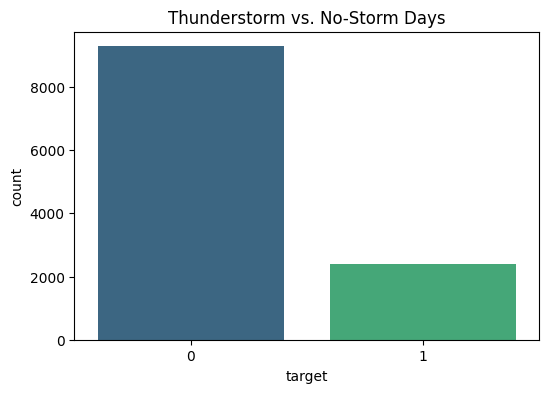

Target Counts:
target
0    0.794813
1    0.205187
Name: proportion, dtype: float64


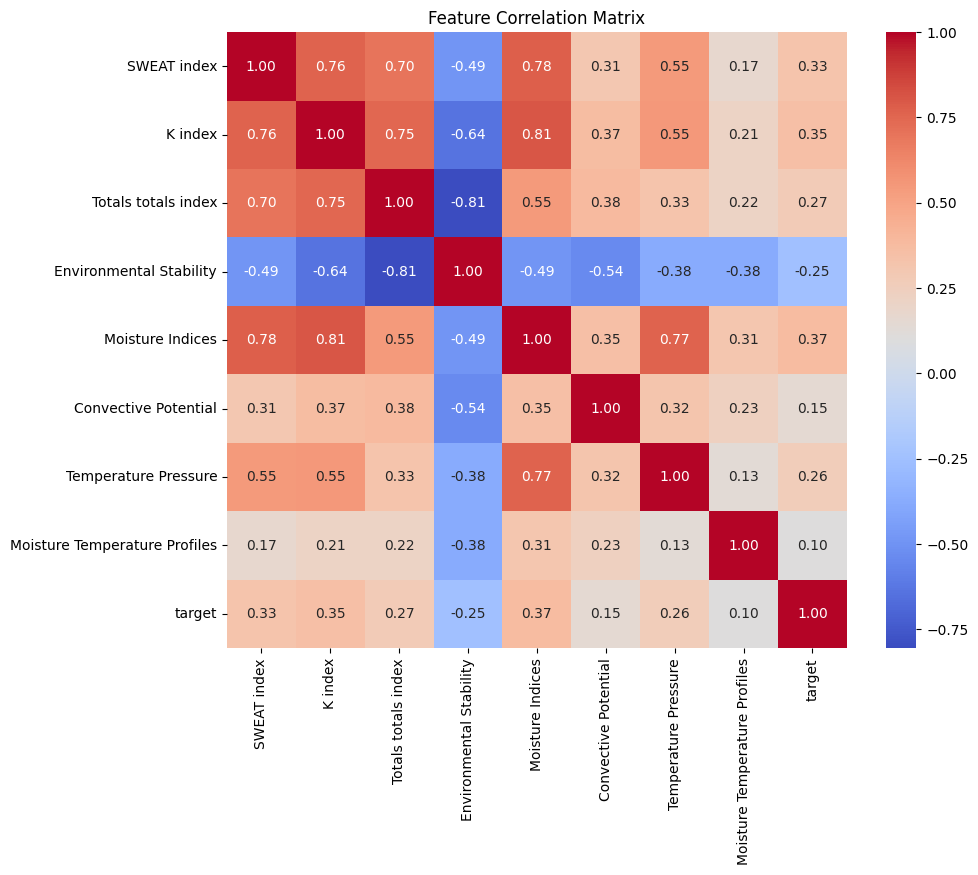

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df_final, palette='viridis')
plt.title('Thunderstorm vs. No-Storm Days')
plt.show()

print("Target Counts:")
print(df_final['target'].value_counts(normalize=True))

# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
# We only want numeric columns
corr_matrix = df_final.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()


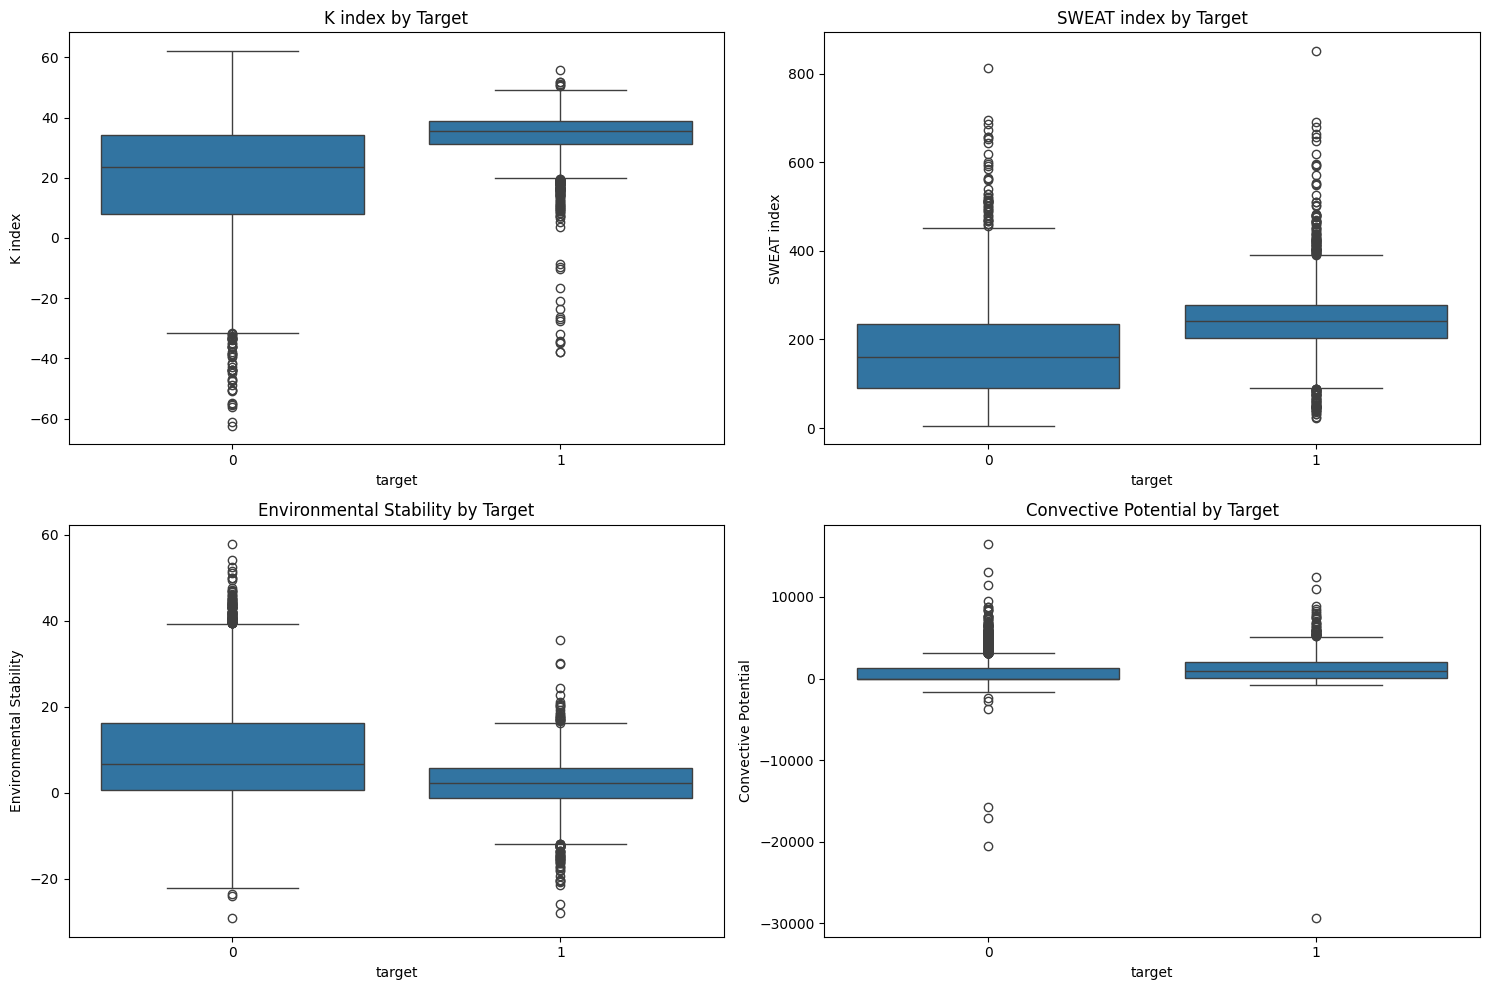

In [52]:
# Focus on 'K index' and 'SWEAT index' as they are classic indicators
features_to_plot = ['K index', 'SWEAT index', 'Environmental Stability', 'Convective Potential']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='target', y=feature, data=df_final)
    plt.title(f'{feature} by Target')

plt.tight_layout()
plt.show()


In [53]:
df_final.to_csv("/Users/mast/Documents/VInayPrograming/Thunder_storm_Predi/data/processed/final.csv",index=False)

In [54]:
from sklearn.model_selection import train_test_split 
X=df_final.drop('target',axis=1)
y=df_final['target']
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,stratify=y,test_size=0.2)

print(f"Training set:{X_train.shape[0]} samples")
print(f"Testing set:{X_test.shape[0]} samples")

print("\nStorm Ration in Training Set:")
print(y_train.value_counts(normalize=True))


Training set:9345 samples
Testing set:2337 samples

Storm Ration in Training Set:
target
0    0.794864
1    0.205136
Name: proportion, dtype: float64


In [55]:
from imblearn.over_sampling import  SMOTE
smote=SMOTE(random_state=42)

X_train_res,y_train_res=smote.fit_resample(X_train,y_train)


print(f"Original Training Distribution:\n{y_train.value_counts()}")

print(f"Resampled Training Distribution:\n{y_train_res.value_counts()}")

Original Training Distribution:
target
0    7428
1    1917
Name: count, dtype: int64
Resampled Training Distribution:
target
0    7428
1    7428
Name: count, dtype: int64


In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix

rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
#Train The Model on our Blanced training data
rf_model.fit(X_train_res,y_train_res)
#Make Predition on the real test data 



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [57]:
y_pred=rf_model.predict(X_test)
print("Classification Report (Standard ML Metrics):")
print(classification_report(y_test, y_pred))

Classification Report (Standard ML Metrics):
              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1857
           1       0.39      0.63      0.48       480

    accuracy                           0.72      2337
   macro avg       0.64      0.69      0.65      2337
weighted avg       0.78      0.72      0.74      2337



In [58]:
# In weather forecasting, standard metrics aren't enough. 
# We need to calculate 
# POD (Probability of Detection), FAR (False Alarm Rate), and CSI (Critical Success Index).


# Tutor Note: POD tells us "Of all actual storms, how many did we catch?". 
# CSI is the overall "Skill Score".


def calculate_scientific_metrics(y_true,y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # POD: True Positives / (True Positives + False Negatives)
    pod = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # FAR: False Positives / (False Positives + True Positives)
    # Note: In meteorology, FAR is often defined as FP / (FP + TP)
    far = fp / (fp + tp) if (fp + tp) > 0 else 0
    
    # CSI: True Positives / (True Positives + False Positives + False Negatives)
    csi = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
    
    return {"POD": pod, "FAR": far, "CSI": csi}

metrics = calculate_scientific_metrics(y_test, y_pred)
print("\n--- Scientific Meteorological Metrics ---")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")



--- Scientific Meteorological Metrics ---
POD: 0.6292
FAR: 0.6098
CSI: 0.3172


In [59]:
import joblib 
import os 
model_dirs='../models'
os.makedirs(model_dirs,exist_ok=True)

model_path=os.path.join(model_dirs,'thunderstorm_rf_model.joblib')

joblib.dump(rf_model,model_path)


['../models/thunderstorm_rf_model.joblib']

In [ ]:
features_path=os.path.join(model_dirs,'Feature_names.joblib')
joblib.dump(final_features,features_path)


['../models/Feature_names.joblib']

In [61]:
print(f"Model saved to: {model_path}")
print(f"Feature metadata saved to: {features_path}")
print("\nCongratulations! Phase 1-5 of the project are complete!")

Model saved to: ../models/thunderstorm_rf_model.joblib
Feature metadata saved to: ../models/Feature_names.joblib

Congratulations! Phase 1-5 of the project are complete!


In [63]:

from xgboost import  XGBClassifier
from sklearn.svm import SVC
import pandas as pd

# Define our Models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

# Create a storage for our results
comparison_results = []

print("Training and Evaluating Models...")

for name, model in models.items():
    print(f"--- Training {name} ---")
    # Train
    model.fit(X_train_res, y_train_res)
    # Predict
    y_pred_val = model.predict(X_test)
    
    # Calculate Scientific Metrics using our previous function
    metrics = calculate_scientific_metrics(y_test, y_pred_val)
    metrics["Model"] = name
    comparison_results.append(metrics)

# Display Comparison Table
df_comparison = pd.DataFrame(comparison_results).set_index("Model")
print("\n--- Model Comparison Dashboard ---")
display(df_comparison)


XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/mast/miniconda3/envs/all/lib/python3.11/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Users/mast/miniconda3/envs/all/lib/python3.11/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.d